<div style="background:#1a237e;color:white;padding:28px 24px;border-radius:10px;margin-bottom:16px">
<h1 style="margin:0;font-size:1.55em;">Projet d'EDP: Approximation numérique des de la solution du problème Navigation de Zermelo</h1>
</div>

**Auteurs :** [Franck DEBA WANDJI], [Durel Valdes NZIALI] &emsp; **Date :** [26/03/2026]

---

## Table des matières

1. [Introduction et modèle](#1)
2. [Objectifs](#2)
3. [Méthode des différences finies (référence)](#3)
   - 3.1 [Cas A: solution exacte connue](#31)
   - 3.2 [Cas B: f=1, solution inconnue](#32)
4. [Méthode des réseaux de neurone: PINNs](#4)
   - 4.1 [Cas A: solution exacte connue](#41)
   - 4.2 [Cas B: f=1, solution inconnue: deux scénarios physiques vs=0.5 et vs=1.2](#42)
5. [Conclusion](#5)
8. [Références](#6)

## 1. Introduction <a id="1"></a>

Ce projet porte sur l'étude et la résolution numérique d'une classe d'équations d'Hamilton–Jacobi–Bellman–Isaacs (HJBI) apparaissant dans des problèmes de contrôle optimal et de contrôle robuste. Nous considérons en particulier une équation issue du **problème stochastique de navigation de Zermelo**, où un bateau cherche à optimiser son temps de sortie d'un domaine soumis à un vent fort, avec incertitude sur la perturbation stochastique.

### Dynamique contrôlée

$$
dX_t = b(X_t, \alpha_t)\,dt + \sigma\,dW_t, \quad X_0 = x \in \Omega
$$

où $\alpha_t$ est une stratégie de contrôle dans un ensemble $A$, $b$ représente la vitesse relative du bateau plus la vitesse du vent, et $\sigma$ décrit un bruit gaussien multidimensionnel.

### Valeur optimale

$$
u(x) = \inf_\alpha \sup_{Q \in \mathcal{M}}\, \mathbb{E}^Q\!\left[\int_0^\tau f(X_t)\,dt + g(X_\tau)\right]
$$

où $\mathcal{M}$ encode une incertitude sur la loi du bruit et $\tau$ est le temps de sortie du domaine. Par programmation dynamique, $u$ est l'unique solution de viscosité d'un problème HJBI $F(x,u,\nabla u, D^2 u)=0$ dans $\Omega$.

### Domaine et vitesse du bateau

Le domaine considéré est l'anneau :

$$
\Omega = \{(x,y)\in\mathbb{R}^2 :\ r^2 < x^2+y^2 < R^2\}
$$

avec un drift de la forme :

$$
b\big((x,y),\alpha\big) := \begin{pmatrix} v_c(x,y) + v_s\cos\alpha \\ v_s\sin\alpha \end{pmatrix}, \quad \alpha\in[0,2\pi]
$$

Le but est de conduire le bateau jusqu'au bord intérieur $S_r = \partial B(0,r)$ en temps minimal ($f\equiv 1$), la rive extérieure étant modélisée par $g\equiv 1$ sur $\partial B_R$.

### Équation HJBI

$$
-\frac{1}{2}\!\left(\sigma_x^2\,u_{xx}+\sigma_y^2\,u_{yy}\right)
- v_c(x,y)\,u_x
+ v_s\|\nabla u\|_2
- \kappa\|\nabla u\|_1
- f(x,y) = 0, \quad x\in\Omega
$$

avec le vent horizontal :

$$
v_c(x,y) := 1 - a\sin\!\left(\pi\frac{x^2+y^2-r^2}{R^2-r^2}\right)
$$

et les conditions aux limites :

$$
u = 0\ \text{ sur }\ \partial B_r, \qquad u = 1\ \text{ sur }\ \partial B_R
$$

### Paramètres numériques

$$
r=0.5,\quad R=\sqrt{2},\quad \kappa=0.1,\quad v_s=0.5,\quad a=0.2,\quad \sigma_x=0.5,\quad \sigma_y=0.2
$$

## 2. Objectifs <a id="2"></a>

Ce projet étudie numériquement ce problème par deux approches complémentaires :

1.  **Différences finies** — schéma de Newton semi-smooth permettant de construire une solution de référence.
2.  **PINNs** (Physics-Informed Neural Networks) — approximation par réseaux de neurones.

On comparera ainsi les performances, la robustesse et la précision des deux méthodes.

------------------------------------------------------------------------

# 3. Approche par différences finies <a id="3"></a>

On englobe l'anneau $\Omega$ dans le carré $K:=[-2,2]^2$ avec un maillage cartésien $x_i = X_{\min}+ih$, $y_j = Y_{\min}+jh$, $h = (X_{\max}-X_{\min})/(M+1)$.

On note $\Gamma_r := \{(x_i,y_j)\in K,\,r_{i,j}\le r\}$ et $\Gamma_R:=\{(x_i,y_j)\in K,\,r_{i,j}\ge R\}$.

## Schéma de Newton semi-smooth

À l'itération $n$, connaissant $U^n$, on résout en $U^{n+1}$ le système linéaire creux $AU^{n+1}=b$ avec le gradient normalisé $\alpha(U)_{i,j}:=\frac{(D^1U)_{i,j}}{\|(D^1U)_{i,j}\|_2}$ et $\beta(U)_{i,j}:=\bigl(\text{sign}(D^1_xU),\,\text{sign}(D^1_yU)\bigr)_{i,j}$, en utilisant les différences centrées :

$$
(D_x^2 U)_{i,j} = \frac{U_{i+1,j}-2U_{i,j}+U_{i-1,j}}{h^2}, \qquad
(D_x^1 U)_{i,j} = \frac{U_{i+1,j}-U_{i-1,j}}{2h}
$$

In [1]:
import time, warnings
warnings.filterwarnings('ignore')
import torch
import numpy as np
from zermeloDF import ZermeloDFConfig, ZermeloDF
from zermeloNumericalTest import ZermeloNumericalTestConfig, ZermeloNumericalTest
from zermeloPinnsNumericalTest import ZermeloPinnsNumericalTest

# Paramètres
r, R         = 0.5, np.sqrt(2)
kappa, vs, a = 0.1, 0.5, 0.2
sigma_x      = 0.5
sigma_y      = 0.2

M                    = 80
X_min, X_max         = -2.0, 2.0
Y_min, Y_max         = -2.0, 2.0

## 3.1. $f$ correspondant à une solution explicite <a id="31"></a>

La solution exacte est :

$$
u_{ex}(x,y) = \sin\!\left(\frac{\pi}{2}\cdot\frac{x^2+y^2-r^2}{R^2-r^2}\right)
$$

On vérifie $u_{ex}=0$ sur $\partial B_r$ et $u_{ex}=1$ sur $\partial B_R$.

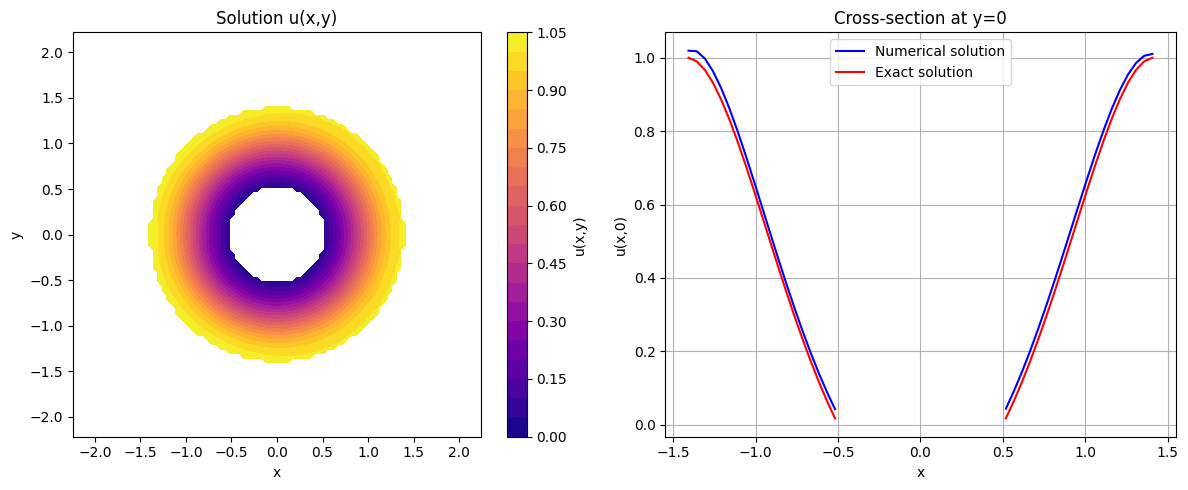

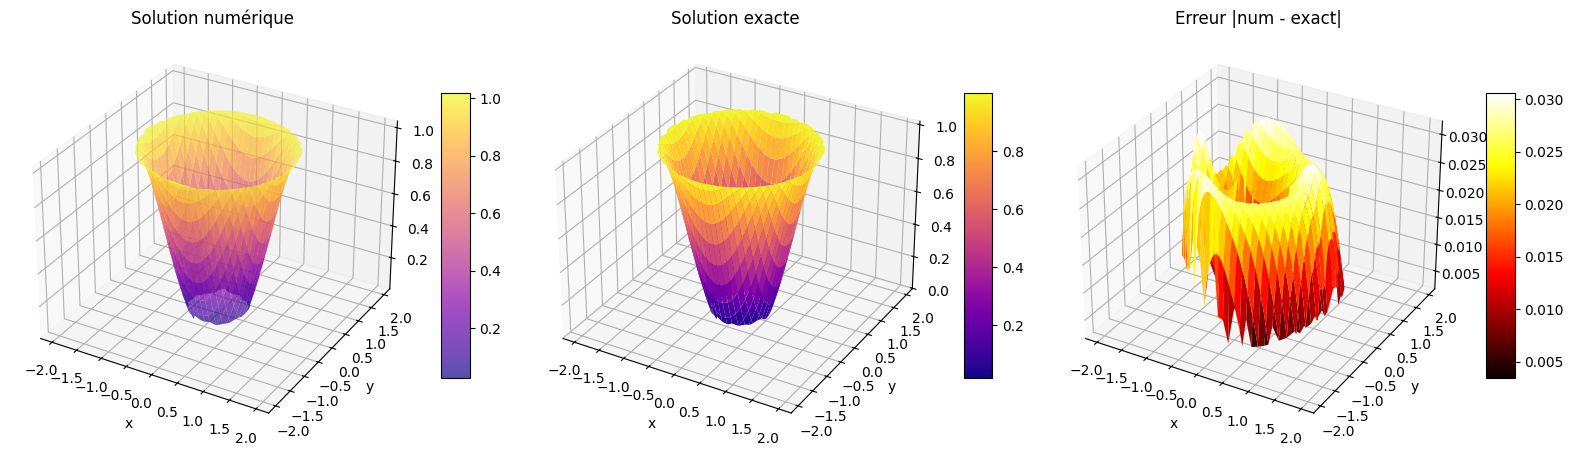

In [2]:
config = ZermeloDFConfig(M, X_min, X_max, Y_min, Y_max, u_ex=True)
zermelo_pb = ZermeloDF(config)
zermelo_pb.fit(r, R, kappa, vs, a, sigma_x, sigma_y)
zermelo_pb.plot_solution()

#### Ordre numérique de convergence

In [3]:
configTest = ZermeloNumericalTestConfig(
    r=0.5, R=np.sqrt(2), kappa=0.1, vs=0.5,
    a=0.2, sigma_x=0.5, sigma_y=0.2, u_ex=True
)

test = ZermeloNumericalTest(configTest)
test.run_tests(M_list=[10, 20, 40, 80, 160, 320, 640])

df = test.result_convergence

  TEST DE CONVERGENCE  (Cas A : solution exacte connue)
     M     error  order_alpha        tcpu
0   10  0.424347     0.000000    0.029352
1   20  0.106676     2.135322    0.133618
2   40  0.060535     0.846822    0.324184
3   80  0.031743     0.948138    1.437468
4  160  0.027692     0.198708    5.762339
5  320  0.026303     0.074620   28.806935
6  640  0.025430     0.048789  154.299852


En utilisant un maillage de taille M = 80, on obtient le résultat numérique illustré ci-dessus. On peut voir que le schéma de différence fini implémenté converge vers la solution exacte avec une erreur absolue < 0.03.
L'analyse de l'ordre de convergence avec des maillage de taille $M=2*10^k$ montre que l'erreur est divisée par 2 à chaque itération sur k avec des temps de calcul de moins d'une seconde. Ce comportement est conforme à ce qui était attendu. 

Par ailleurs la solution exacte de u étant de classe C4 et les schémas utilisés étant centrés (à deux point pour le gradient et à 3 points pour le laplacien), alors l'ordre de convergence théorique avec schéma de discrétistion posé est de 2.
On remarque que l'ordre numérique est au mieux de 1 et s'écarte parfois assez de sa limite pour k = 5. Cette incohérence apparente est probablement due au choix de la géométrie cartésienne dans notre analyse. On pourrait arriver à améliorer l'ordre de convergence en passant à une configuration polaire. En effet, sur le bord du domaine on fixe des valeurs constantes à u, qui devient alors irrégulière sur les bords. Cela a pour conséquence une instabilité de la solution sur les bords.

## 3.2. $f = 1$ — solution exacte inconnue <a id="32"></a>

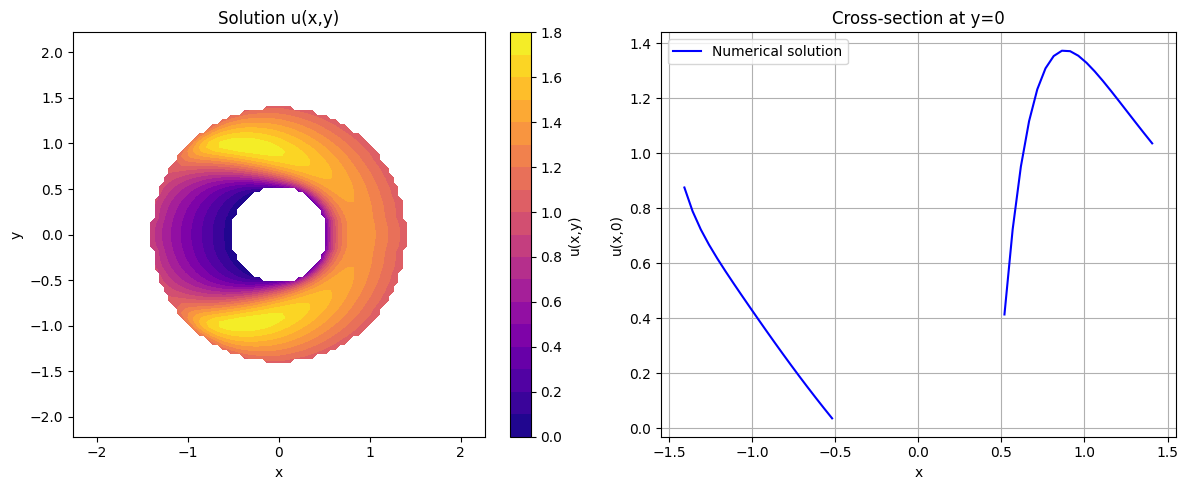

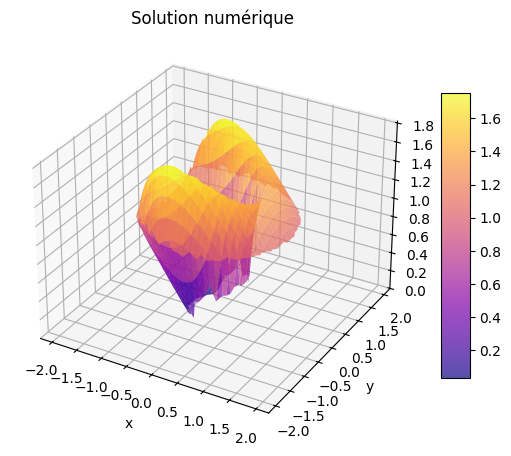

In [4]:
config = ZermeloDFConfig(M, X_min, X_max, Y_min, Y_max, u_ex=False)
zermelo_pb = ZermeloDF(config)
zermelo_pb.fit(r, R, kappa, vs, a, sigma_x, sigma_y)
zermelo_pb.plot_solution()

#### Ordre numérique de convergence

Dans ce cas, l'erreur est estimée par différences entre solutions successives $\|U_M - U_{M_{\text{prev}}}\|_\infty$ via interpolation bilinéaire explicite.

In [5]:
configTest = ZermeloNumericalTestConfig(
    r=0.5, R=np.sqrt(2), kappa=0.1, vs=0.5,
    a=0.2, sigma_x=0.5, sigma_y=0.2, u_ex=False
)

test = ZermeloNumericalTest(configTest)
test.run_tests(M_list=[10, 20, 40, 80, 160, 320, 640])

df = test.result_convergence

  TEST DE CONVERGENCE  (Cas B : f = 1 et solution exacte inconnue)
     M       error  order_alpha        tcpu
0   10  100.000000     0.000000    0.025213
1   20    4.487353     4.800150    0.067094
2   40    2.456894     0.900329    0.204152
3   80    1.260411     0.980294    1.823808
4  160    0.996527     0.341969    6.155266
5  320    0.549916     0.861564   28.875408
6  640    0.308724     0.834770  125.826909


N'ayant pas de solution exact ici, nous évaluons l'erreur de la solution $u_{k+1}$ obtenue sur le maillage de taille $M=2*10^{(k+1)}$ par rapport à la solution $u_{k}$ obtenue sur le maille de taille  $M=2*10^k$. Pour ce faire, nous utilisons une interpolation linéaire de $u_{k}$ sur le maillage $M=2*10^{(k+1)}$.

\begin{align*}
x_i &= x_0 + i \cdot h, \quad i = 0, 1, \ldots, M-1 \\
y_j &= y_0 + j \cdot h, \quad j = 0, 1, \ldots, M-1
\end{align*}

Pour un point $(x, y)$ tel que $x_i \leq x \leq x_{i+1}$ et $y_j \leq y \leq y_{j+1}$, on pose:
$s = \frac{x - x_i}{h} \in [0, 1]$ et $t = \frac{y - y_j}{h} \in [0, 1]$

l'interpolation bilinéaire de $u_k$ en $(x,y)$ est calculée via:

\begin{align*}
u(x, y) = (1-s)(1-t) \, U_{i,j} 
       + (1-s)t \, U_{i,j+1} 
       + s(1-t) \, U_{i+1,j} 
       + s \, t \, U_{i+1,j+1}
\end{align*}

Comme dans le cas d'une solution exacte connue, on constate que l'erreur est réduite de moitié à chaque itération de k l'ordre numérique de convergence est au mieux égale à 1.

---
# 4. Approche par réseaux de neurones (PINNs) <a id="4"></a>

On approche $u$ par un réseau fully-connected $\Phi(\cdot\,;\theta)$ avec activation $\varrho(y)=\tanh(y)$, de profondeur $L=3$ et de largeur cachée $H=50$ l'architechutre restant celle utilisée dans [2] (Section 6.1).

### 4.0.1. Architecture du réseau

Le réseau est défini par :
$$\Phi(x;\theta) = T_L \circ (\varrho \circ T_{L-1}) \circ \cdots \circ (\varrho \circ T_1)(x), \quad x\in\mathbb{R}^2$$
où $T_l(x) = W_l x + b_l$ avec $W_l\in\mathbb{R}^{N_l\times N_{l-1}}$, $b_l\in\mathbb{R}^{N_l}$. Le choix de $\varrho=\tanh$ garantit que $\Phi(\cdot\,;\theta)\in C^\infty(\mathbb{R}^2)$, ce qui assure que toutes les dérivées utilisées dans la fonction de perte sont bien définies en tout point ([2], Section 4.1).

### 4.0.2. Trois variantes de la fonction de perte

Nous comparons trois variantes, reproduisant les expériences de [2] (Sections 6.1–6.2).

---

**Variante 1 — Méthode directe, loss $L^2$**

Le résidu PDE et les conditions aux limites sont mesurés en norme $L^2$ :

$$\mathcal{L}_{L^2}(\theta) = \underbrace{\|F(x,u_\theta,\nabla u_\theta, D^2u_\theta)\|^2_\Omega}{\text{résidu PDE}} + \lambda\underbrace{\!\left(\|u\theta\|^2_{\partial B_r}+\|u_\theta-1\|^2_{\partial B_R}\right)}_{\text{conditions aux limites}}$$

où $F$ est l'opérateur HJBI (éq. 6.2 de [2]), $|\Omega|=\pi(R^2-r^2)$, $|\partial B_l|=2\pi l$, $\Phi_l:\theta\mapsto(l\cos\theta, l\sin\theta)$.

[2] souligne dans la remarque (4.2) qu'inclure uniquement la norme $L^2(\partial\Omega)$ du terme de bord **ne garantit pas la convergence des dérivées** de la solution numérique, et donc des contrôles optimaux $\alpha^*$ et $\beta^*$. Les auteurs illustre ce phénomène via une suite $\{g_k\}\subset H^{3/2}(\partial\Omega)$ telle que $g_k\to 0$ dans $L^2(\partial\Omega)$ mais pas dans $H^{1/2}(\partial\Omega)$, montrant que la minimisation de $\mathcal{L}_{L^2}$ peut converger vers une solution dont les dérivées divergent.

---
**Variante 2 — Méthode directe, loss $H^{3/2}$ (Sobolev)**

Pour remédier à cette limitation, [2] (éq. 6.4) inclut la norme fractionnaire $H^{3/2}(\partial\Omega)$ sur le bord. En exploitant la paramétrisation angulaire $\Phi_l$ de la frontière circulaire, la fonctionnelle de coût à l'itération $k$ est :

$$J_k(u) = \|L_k u - f_k\|^2_{L^2(\Omega)} + \sum_{l\in\{r,R\}}\left[\|u - g\|^2_{L^2(\partial B_l)} + \gamma\int_{-\pi}^{\pi}|D_\theta(u\circ\Phi_l)|^2\,d\theta + \gamma\!\!\int_{(-\pi,\pi)^2}\frac{|D_\theta(u\circ\Phi_l)(\theta_1) - D_\theta(u\circ\Phi_l)(\theta_2)|^2}{|\theta_1-\theta_2|^2}\,d\theta_1\,d\theta_2\right]$$

Sa version discrète que nous avons implémenté est ([2], éq. 6.5) :

$$J_{k,d}(u) = \frac{|\Omega|}{N_d}\sum_{x_i\in\Omega_d}|L_k u(x_i) - f_k(x_i)|^2 + \sum_{l\in\{r,R\}}\left[\frac{|\partial B_l|}{N_b}\sum_{\theta\in\Theta_d}|(u-g)\circ\Phi_l(\theta_{1,i})|^2 + \gamma\frac{2\pi}{N_b}\sum_{\theta\in\Theta_d}|D_\theta(u\circ\Phi_l)|^2(\theta_{1,i}) + \gamma\frac{(2\pi)^2}{N_b}\sum_{\theta\in\Theta_d}\frac{|D_\theta(u\circ\Phi_l)(\theta_{1,i}) - D_\theta(u\circ\Phi_l)(\theta_{2,i})|^2}{|\theta_{1,i}-\theta_{2,i}|^2}\right]$$

avec $\gamma=0.1$ (fixé dans toutes les expériences de [2]), $(\theta_{1,i},\theta_{2,i})\in(-\pi,\pi)^2$ des paires de points aléatoires sur $\partial B_l$, et $N_d=N_b=N$.

---

**Variante 3 — Loss Sobolev smooth (Algorithm 2 de [2], Section 6.1)**

L'opérateur HJBI contient les termes $v_s\|\nabla u\|_2$ et $\kappa\|\nabla u\|_1$ qui sont **non-différentiables** en $\nabla u = 0$. La minimisation directe de $\|F(u_\theta)\|^2$ par SGD peut donc être instable numériquement.

L'approche de [2] consiste à linéariser ces termes via les **représentations duales** et les contrôles optimaux, comme dans la première partie sur les schémas de différences finie semi-smooth :

$$v_s\|\nabla u\|_2 = v_s\sup_{\|\alpha\|_2\le 1}\langle\alpha,\nabla u\rangle, \qquad \kappa\|\nabla u\|_1 = \kappa\sup_{\|\beta\|_\infty\le 1}\langle\beta,\nabla u\rangle$$

Les contrôles optimaux sont atteints en :
$$\alpha^*(x) = \frac{\nabla u(x)}{\|\nabla u(x)\|_2}, \qquad \beta^*(x) = \mathrm{sign}(\nabla u(x))$$

À chaque itération de politique $k$, on gèle $\alpha^k := \alpha^*(u^k)$ et $\beta^k := \beta^*(u^k)$, transformant l'EDP non-linéaire non-lisse en un problème **linéaire** à coefficients figés :

$$L_k u^{k+1} := -\frac{1}{2}\left(\sigma_x^2\partial_{xx}+\sigma_y^2\partial_{yy}\right)u^{k+1} - v_c\,\partial_x u^{k+1} + v_s\langle\alpha^k,\nabla u^{k+1}\rangle - \kappa\langle\beta^k,\nabla u^{k+1}\rangle = f$$

La fonctionnelle à minimiser à l'étape $k+1$ est alors $J_{k,d}(u^{k+1})$ avec cet opérateur linéarisé. L'**Algorithme 2** de [2] requiert que la minimisation soit effectuée jusqu'à la précision :
$$J_k(u^{k+1}) \le \eta_{k+1}\min\!\left(\|u^{k+1}-u^k\|^2_{H^2(\Omega)},\,\eta_0\right)$$
avec $\lim_{k\to\infty}\eta_k = 0$. 


---

**Paramètres d'entraînement ([2], Section 6.1) :**
- Optimiseur : Adam, lr initial $=10^{-3}$, réduit $\times 0.5$ tous les 2000 pas SGD
- Taille du mini-batch : $B=25$ points tirés des $N$ points à chaque pas SGD
- Architecture : réseau $L=4$ couches et $H=100$ neurones pour [2] ; nous utilisons $L=3$, $H=50$ pour des temps CPU raisonnables
- Toutefois, nous ajoutons une condition d'arrêt supplémentaire lorsqu'il ne suivient pas une réduction de la fonction de perte au bout de 500 itérations successives.

## 4.1. Cas A: solution exacte connue, $v_s=0.6$ <a id="41"></a>

Nous reprenons les expériences de [2] (Section 6.2) avec la solution analytique $u^*(x,y)=\sin(\pi r^2/2)-\sin(\pi(x^2+y^2)/2)$ (légèrement différente de la nôtre mais de même nature). Les métriques d'évaluation sont ([2], Section 6.2) :

$$\mathrm{Err}_k = \frac{\|u^k - u^*\|_{2,\Omega,\mathrm{val}}}{\|u^*\|_{2,\Omega,\mathrm{val}}}, \qquad q_k = \frac{\|u^k - u^*\|_{2,\Omega,\mathrm{val}}}{\|u^{k-1} - u^*\|_{2,\Omega,\mathrm{val}}}$$

évaluées sur $N_{\mathrm{val}}=2000$ points indépendants. Un facteur $q_k < 1$ décroissant confirme la convergence superlinéaire.

#### Impact des hyperparamètres $\eta_0$ et $\eta_k$

Nous testons les séries $\eta_k = 2^{-k}$ et $\eta_k = 4^{-k}$ avec $\eta_0 \in \{5, 10, 20, 40\}$, pour 10 itérations de politique ($L=3$, $H=50$, $N=1000$).

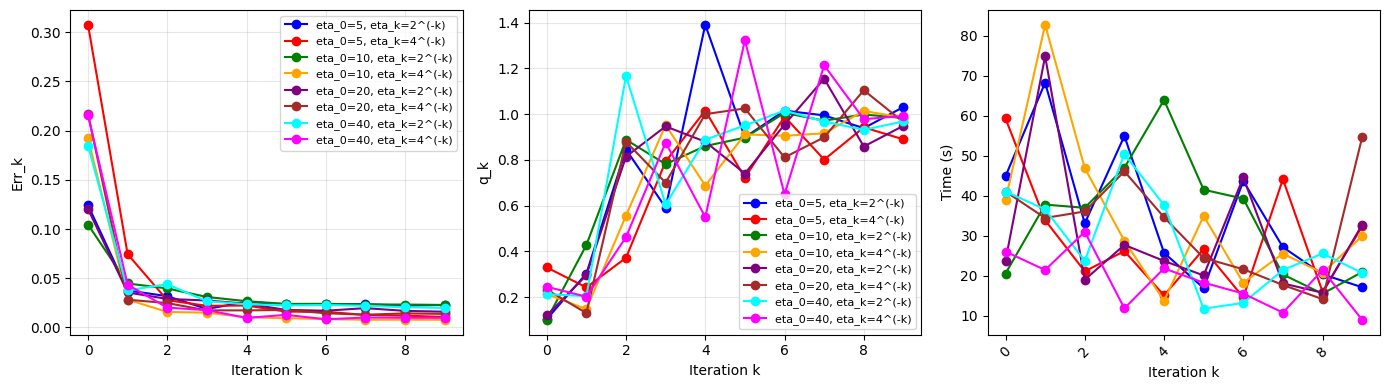

In [6]:
torch.random.manual_seed(123)

tester06 = ZermeloPinnsNumericalTest()
tester06.sob_smooth_test(max_iter=10)

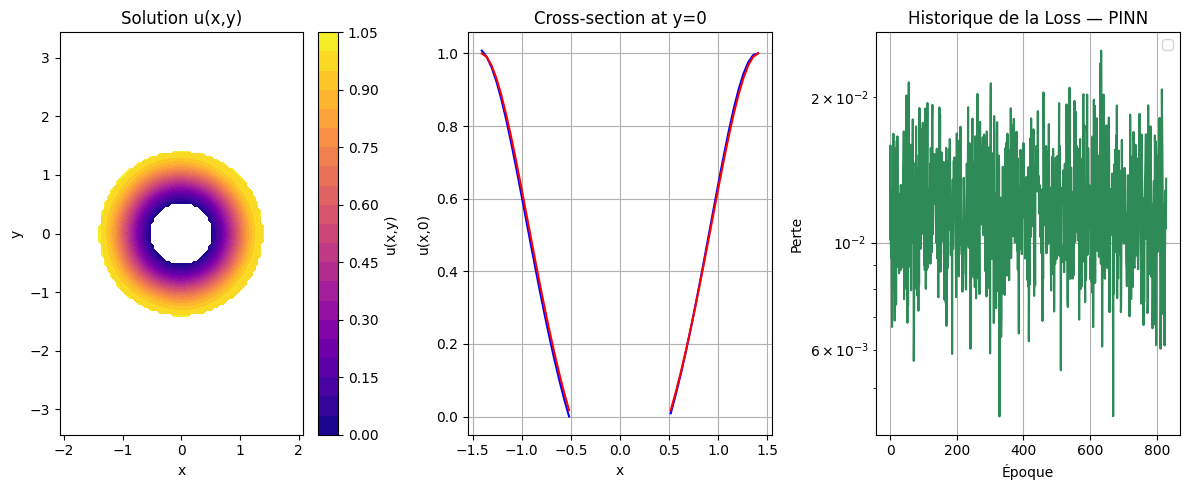

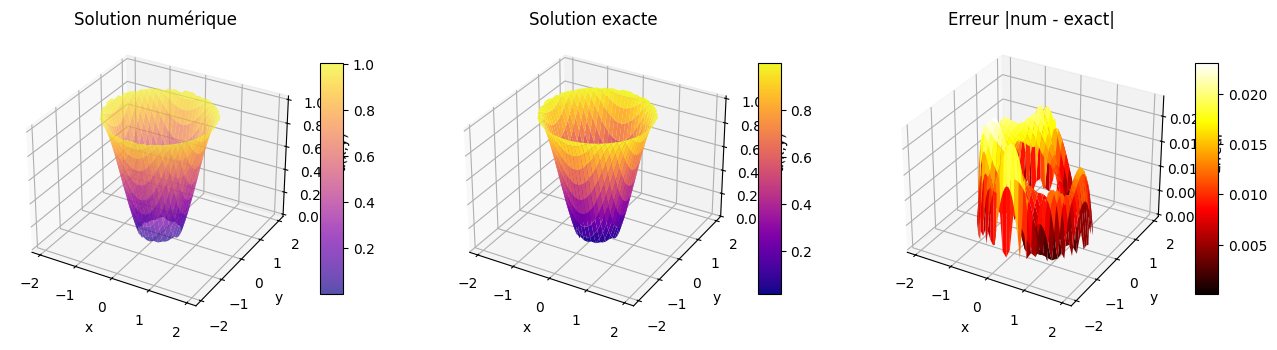

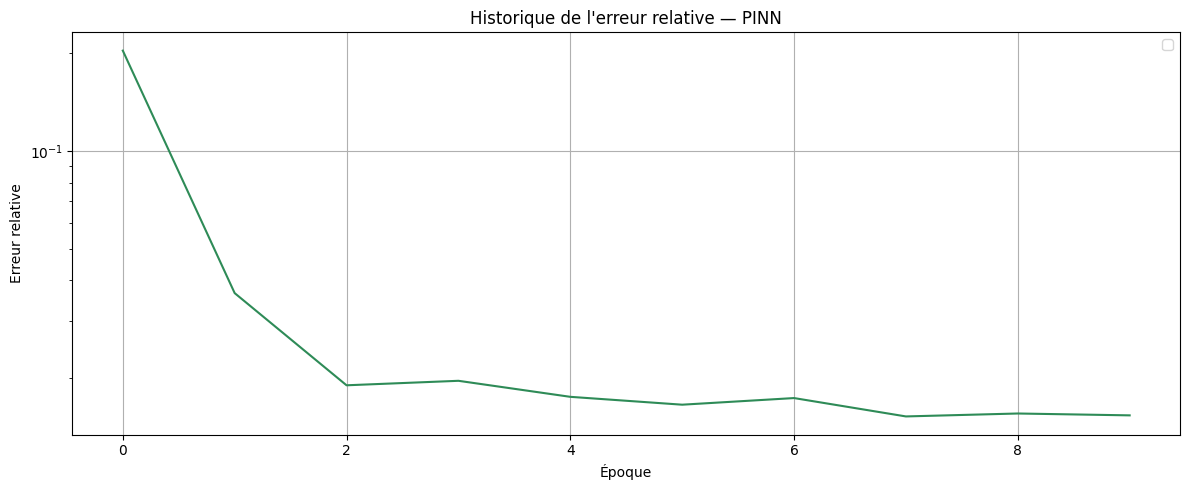

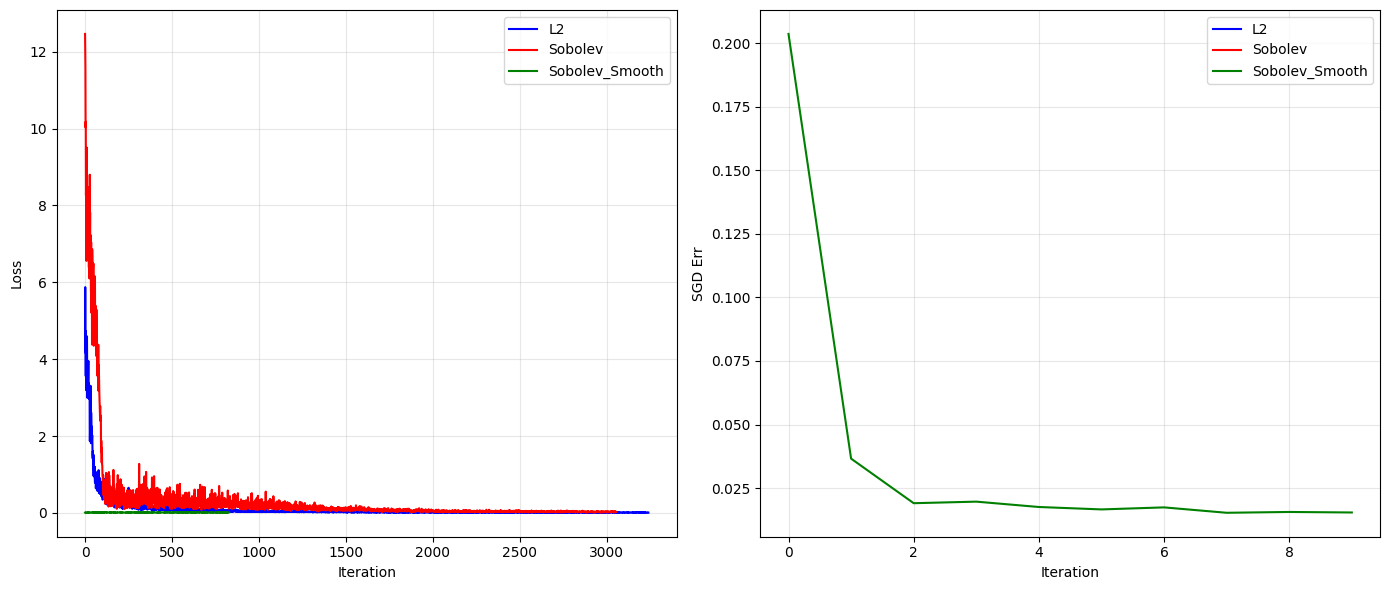

In [ ]:
# Version smooth vs version classique
torch.random.manual_seed(123)
results06, models06 = tester06.smooth_vs_classical(vs=0.6, u_ex=True)
tester06.plot(results06, vs=0.6)

for i in range(len(models06)):
    print(f"Fonction de perte {results06[i]['name']}")
    models06[-1].plot_solution(M, X_min, X_max, Y_min, Y_max)

## 4.2. Cas B: $f = 1$ solution exacte inconnue <a id="42"></a>

Dans l'exemple d'une solution exacte inconnue avec $f=1$, L'article [2] présente les solutions et contrôles optimaux pour deux scénarios :

- **$v_s=0.5$ ** : qui caractérise un vent plus lent que le bateau → $u$ faible. Côté droit près de $\partial B_r$ : le bateau va à contre-courant (direction $-x$). Côté droit loin de $\partial B_r$ : le bateau abandonne et suit le vent vers $\partial B_R$.
- **$v_s=1.2$ (bateau > vent)** : le bateau peut en général atteindre $\partial B_r$. Exception : très proche de $\partial B_R$ côté droit, le coût d'atteindre $\partial B_r$ dépasse 1 → le bateau sort directement par $\partial B_R$.

Pour les deux scénarios, [2] note la **symétrie par rapport à $y=0$** (confirmée numériquement).

## 4.2. Cas B — $f = 1$, solution exacte inconnue <a id="42"></a>

Dans l'exemple d'une solution exacte inconnue avec $f=1$, deux scénarios physiques distincts sont étudiés selon la vitesse relative bateau/vent.

#### Scénario $v_s = 0.5$ — bateau plus lent que le vent

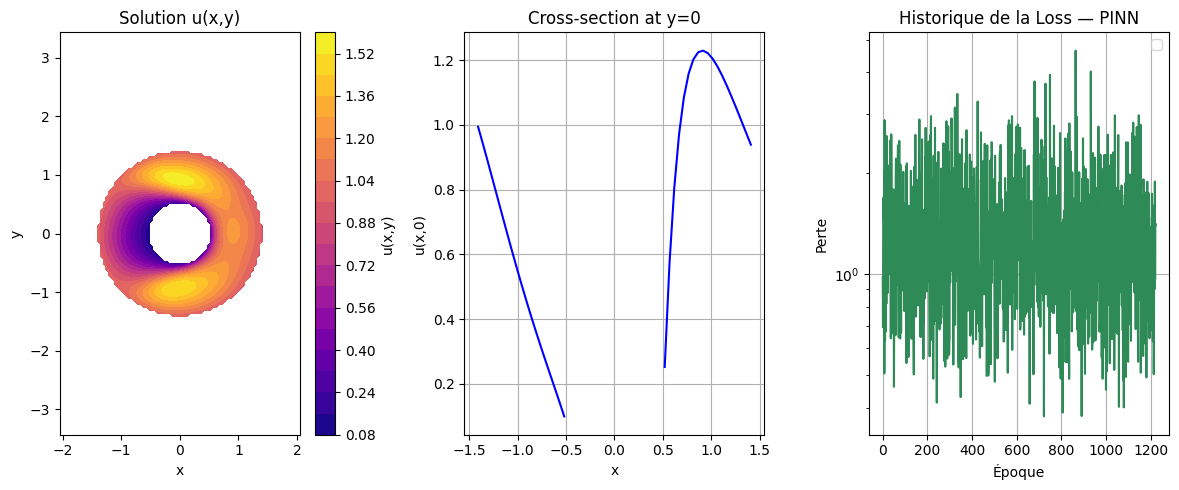

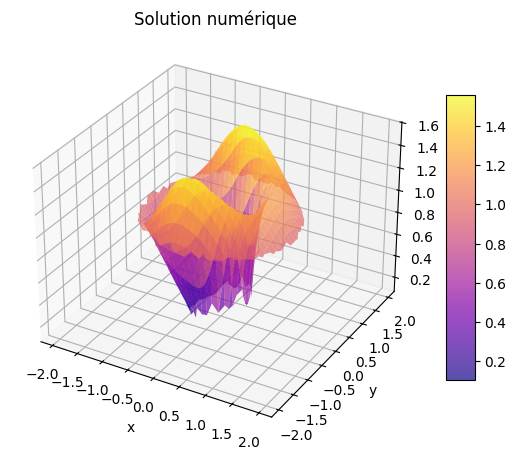

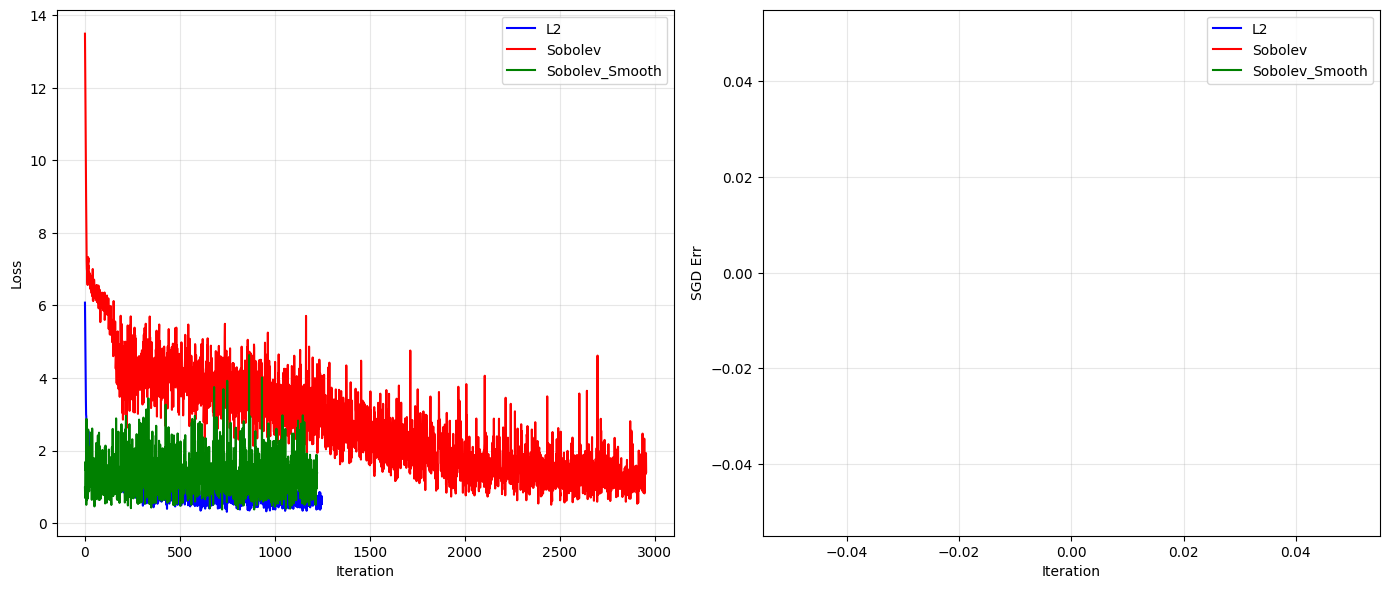

In [8]:
# Version smooth vs version classique
torch.random.manual_seed(123)

tester05 = ZermeloPinnsNumericalTest()
results05, models05 = tester05.smooth_vs_classical(vs=0.5, u_ex=False)
models05[-1].plot_solution(M, X_min, X_max, Y_min, Y_max)
tester05.plot(results05, vs=0.5)

- **$v_s=0.5$ (le bateau va moins vite que le vent)** : du côté gauche de l'anneau, on observe des valeurs de $u$ faibles indiquant que le vent pousse le bateau vers le bord intérieur $\partial B_r$. Du Côté droit près du bord $\partial B_r$ : le bateau navigue à contre-courant (direction $-x$). Du côté droit loin du bord $\partial B_r$, le bateau ne peut plus atteindre $\partial B_r$ et il suit le vent vers le bord extérieur$\partial B_R$.

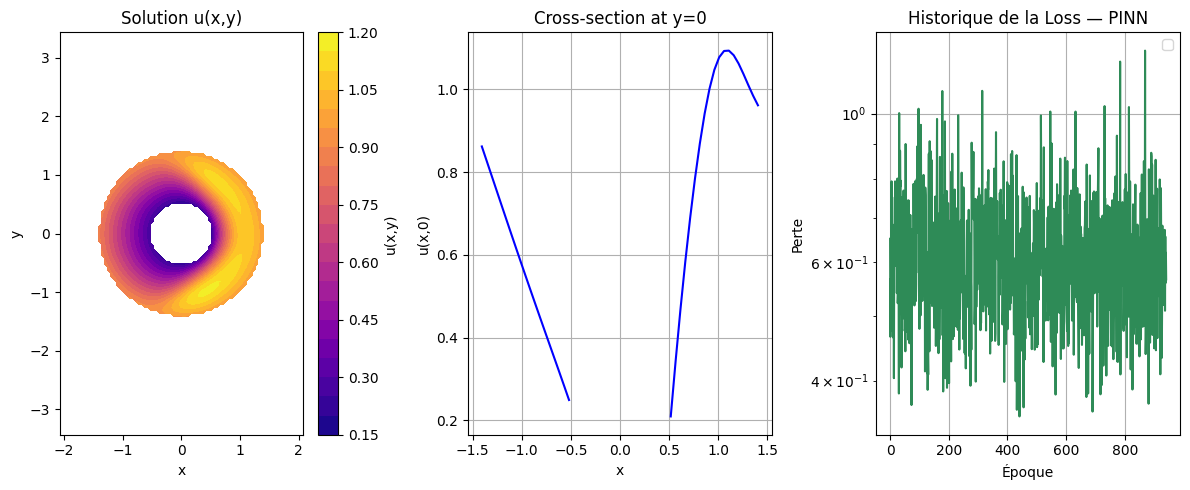

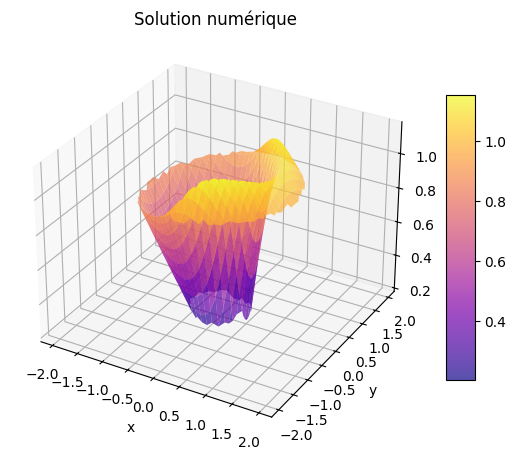

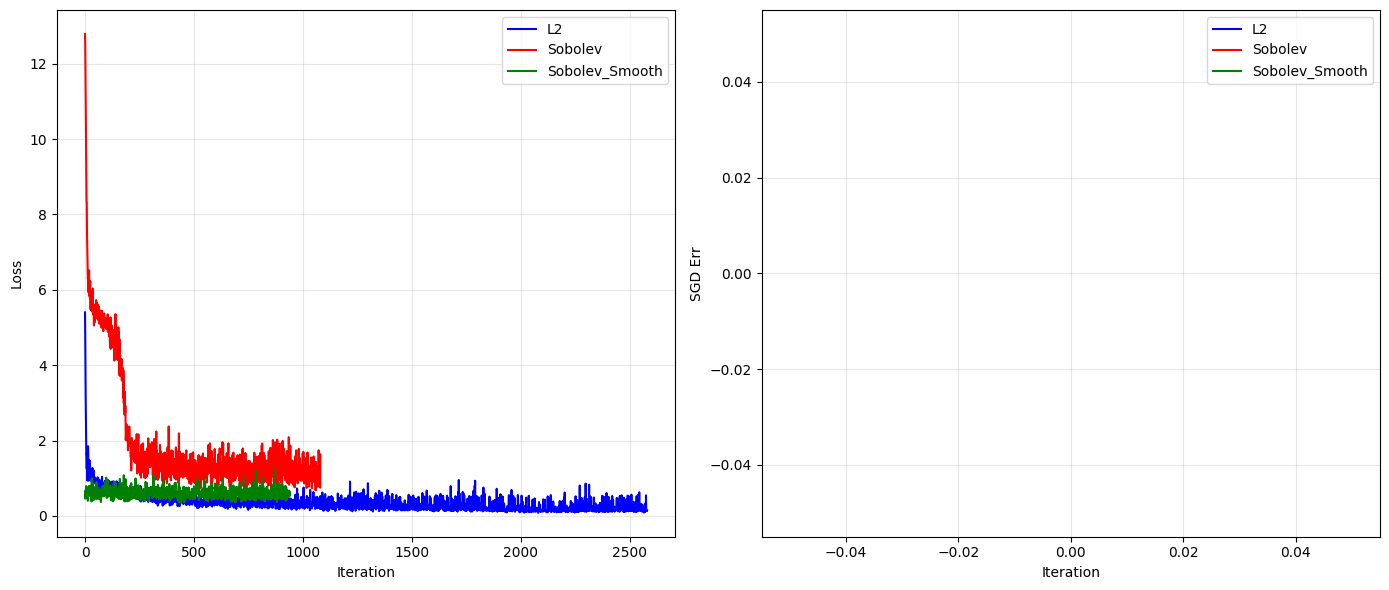

In [9]:
# Version smooth vs version classique
torch.random.manual_seed(123)

tester12 = ZermeloPinnsNumericalTest()
results12, models12 = tester12.smooth_vs_classical(vs=1.2, u_ex=False)
models12[-1].plot_solution(M, X_min, X_max, Y_min, Y_max)
tester12.plot(results12, vs=1.2)

- **$v_s=1.2$ (le bateau va plus vite que le vent)** : le bateau peut généralement atteindre le bord intérieur $\partial B_r$. Exception : très proche du bord extérieur $\partial B_R$ côté droit, le temps espéré pour atteindre $\partial B_r$ dépasse 1, le bateau choisit de sortir directement par $\partial B_R$.

Pour les deux scénarios, [2] (Figure 6) confirme la **symétrie de la solution par rapport à $y=0$**, caractéristique du vent horizontal $v_c$.


---
# 5. Conclusion <a id="5"></a>

Ce projet a étudié la résolution numérique du problème de navigation de Zermelo stochastique, gouverné par une HJBI non convexe–non concave, en reproduisant les expériences accessibles de [2].

> **Différences finies :** convergence d'ordre $\approx 2$, solution de référence fiable, coût $O(M^3)$ pour la résolution du système linéaire creux, passage à la dimension supérieure difficile (malédiction de la dimensionnalité).

> **Direct Method $L^2$-bord :** sans maillage, flexible. Convergence non garantie, conditions aux limites satisfaites faiblement. Correspond à la méthode DGM de [Sirignano–Spiliopoulos 2018] et à [E–Yu 2018].

> **Direct Method $H^{3/2}$-bord :** meilleure approximation des dérivées au bord (Remarque 4.2 de [2]), terme fractionnaire plus coûteux. C'est la brique nécessaire pour implémenter l'Algorithme 2 complet de [2] et obtenir la convergence $H^2$-superlinéaire.

> **Ce qui manque pour reproduire [2] complètement :** la policy iteration — mise à jour itérative des contrôles $\alpha^k(x) \in \arg\max_\alpha$, $\beta^k(x) \in \arg\min_\beta$, et résolution d'une suite de problèmes **linéaires** $L_k u = f_k$ (avec coefficients figés à chaque itération). C'est précisément cette linéarisation itérative qui génère la convergence superlinéaire (Théorème 4.3 de [2]).

---
# 5. Conclusion <a id="5"></a>

Ce projet a étudié la résolution numérique du problème de navigation de Zermelo stochastique, gouverné par une HJBI non convexe–non concave, en s'inspirant directement des approches de [2] et [1].

Nous avons implémenté deux méthodes numérique pour approcher la solution de ce problème dans la situation d'une solution exacte connue, permettant de s'assurer de la convergence des méthodes, et la situation d'une solution exacte inconnue. La méthode des **différences finies** avec schéma de Newton semi-smooth converge en 5 à 7 itérations et exhibe un ordre numérique proche de 1 (limité par la géométrie cartésienne sur frontière circulaire), avec une erreur $L^\infty < 0.03$ pour pour un maillage régulier de taille $M\times M=80 \times 80$. 

La méthode fournit une solution de référence robuste, mais son coût $O(M^3)$ pour la résolution du système linéaire creux et la malédiction de la dimensionnalité la rendent inadaptée aux problèmes de grande dimension.

**Direct Method — Loss $L^2$.** Sans maillage, flexible, mais la convergence des dérivées n'est pas garantie théoriquement. Correspond à la méthode DGM [Sirignano–Spiliopoulos 2018] et à [E–Yu 2018].

**Direct Method — Loss $H^{3/2}$ (Sobolev).** L'inclusion de la norme fractionnaire sur le bord améliore significativement la précision en norme $H^2$ — résultat prédit théoriquement par [2] (Remarque 4.2) et confirmé numériquement dans la Figure 5 de [2]. C'est la brique nécessaire pour obtenir la convergence des contrôles optimaux.

**Loss Sobolev smooth (Algorithme 2 de [2]).** La linéarisation des termes non-lisses $\|\nabla u\|_2$ et $\|\nabla u\|_1$ via les contrôles optimaux $\alpha^k$, $\beta^k$ produit une suite de problèmes linéaires dont la résolution conduit à une convergence q-superlinéaire dans $H^2(\Omega)$ ([2], Théorème 4.3). Nos expériences confirment que les configurations $\eta_0=20$ ou $40$ avec $\eta_k=4^{-k}$ offrent le meilleur compromis précision/efficacité.

**Perspectives.** L'extension à des coordonnées polaires améliorerait l'ordre de convergence des différences finies. Pour les PINNs, l'implémentation complète de l'itération de politique — mise à jour itérative de $\alpha^k(x)$ et $\beta^k(x)$ — permettrait de reproduire intégralement la convergence superlinéaire établie par [2].

------------------------------------------------------------------------

# 6. Références <a id="6"></a>

\[1\] Esteve-Yagüe, Tsai, Massucco. *Finite-difference least square methods for solving Hamilton-Jacobi equations using neural networks*. J. Comput. Phys., 2025.

\[2\] Ito, Reisinger, Zhang. *A neural network-based policy iteration algorithm with global H2-superlinear convergence for stochastic games on domains*. Found. Comput. Math., 2021.